### Tablet Counting Model (YOLO)

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.7 MB/s eta 0:00:00


In [2]:
import os
import shutil
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
import torch
import time
from sklearn.model_selection import train_test_split
import glob
import random
from collections import Counter

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import torch
import sys

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')

print('PyTorch Version:', torch.__version__)
print('-' * 60)
if torch.cuda.is_available():
    print('CUDA Device Count:', torch.cuda.device_count())
    print('CUDA Device Name:')
    for i in range(torch.cuda.device_count()):
        print('\t', torch.cuda.get_device_name(i))
    print('CUDA Current Device Index:', torch.cuda.current_device())
    print('-' * 60)

print(f"Python version = {sys.version}")

PyTorch Version: 2.9.0+cu126
------------------------------------------------------------
CUDA Device Count: 1
CUDA Device Name:
	 Tesla T4
CUDA Current Device Index: 0
------------------------------------------------------------
Python version = 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Navigate to your folder
FOLDERNAME = 'Model (GPU)'
%cd '/content/drive/My Drive/{FOLDERNAME}'

# Verify you're in the right directory
print("Current directory:", os.getcwd())
print("Files in current directory:")
for item in os.listdir('.'):
    print(f"  - {item}")

Mounted at /content/drive
/content/drive/My Drive/Model (GPU)
Current directory: /content/drive/My Drive/Model (GPU)
Files in current directory:
  - sodbicab.jpg
  - hydra.jpg
  - levo.jpg
  - NaCl.jpg
  - Augmented Dataset
  - CountingPills.v36i.yolov8
  - Pill Detection.v5-isolate-objects.yolov8
  - combined_pill_dataset
  - yolov8n.pt
  - runs
  - yolo11n.pt
  - Augmented Dataset 2
  - yolov8m.pt
  - yolov8s.pt
  - count.ipynb


In [5]:
# Adjust paths to match your Drive folders
!cp -r "/content/drive/MyDrive/Model (GPU)/Pill Detection.v5-isolate-objects.yolov8" "/content/"
!cp -r "/content/drive/MyDrive/Model (GPU)/CountingPills.v36i.yolov8" "/content/"
!cp -r "/content/drive/MyDrive/Model (GPU)/Augmented Dataset 2" "/content/"

In [6]:
import os
import time
import shutil
from pathlib import Path
import glob

def prepare_combined_dataset():
    datasets = {
        'single_pills': '/content/Pill Detection.v5-isolate-objects.yolov8',
        'multiple_pills': '/content/CountingPills.v36i.yolov8',
        'augmented_dataset': '/content/Augmented Dataset 2'
    }

    # Remove existing combined dataset
    combined_dir = Path('/content/combined_pill_dataset')
    if combined_dir.exists():
        print("Removing existing combined dataset...")
        shutil.rmtree(combined_dir)

    # Create fresh directories
    combined_dir.mkdir(exist_ok=True)
    for split in ['train', 'val', 'test']:
        (combined_dir / split / 'images').mkdir(parents=True, exist_ok=True)
        (combined_dir / split / 'labels').mkdir(parents=True, exist_ok=True)

    total_images = 0
    detailed_stats = {}
    combined_split_counts = {'train': 0, 'val': 0, 'test': 0}

    # Global counter to ensure unique filenames across all datasets
    global_counters = {'train': 1, 'val': 1, 'test': 1}

    for dataset_name, dataset_path in datasets.items():
        print(f"\nProcessing {dataset_name}...")
        dataset_path = Path(dataset_path)

        if not dataset_path.exists():
            print(f"Dataset {dataset_path} not found. Skipping...")
            detailed_stats[dataset_name] = {'train': 0, 'val': 0, 'test': 0}
            continue

        detailed_stats[dataset_name] = {'train': 0, 'val': 0, 'test': 0}
        dataset_image_count = 0

        # Split variations to check
        split_variations = {
            'train': ['train', 'training'],
            'val': ['val', 'valid', 'validation'],
            'test': ['test', 'testing']
        }

        for target_split in ['train', 'val', 'test']:
            split_found = False

            for split_name in split_variations[target_split]:
                source_img_dir = dataset_path / split_name / 'images'
                source_label_dir = dataset_path / split_name / 'labels'

                if source_img_dir.exists():
                    split_found = True
                    print(f"   Found {split_name} split")

                    target_img_dir = combined_dir / target_split / 'images'
                    target_label_dir = combined_dir / target_split / 'labels'

                    # Get all image files
                    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG', '*.JPEG', '*.PNG', '*.BMP']
                    image_files = []
                    for ext in image_extensions:
                        image_files.extend(source_img_dir.glob(ext))

                    print(f"     Found {len(image_files)} images to copy")

                    if len(image_files) == 0:
                        print(f"     No images found in {source_img_dir}")
                        break

                    copied = 0
                    for img_file in image_files:
                        try:
                            # Create unique filename using global counter
                            file_extension = img_file.suffix.lower()
                            new_name = f"{dataset_name}_{target_split}_{global_counters[target_split]:06d}{file_extension}"
                            target_path = target_img_dir / new_name

                            # Copy image
                            shutil.copy2(img_file, target_path)

                            # Copy corresponding label if exists
                            label_file = source_label_dir / f"{img_file.stem}.txt"
                            if label_file.exists():
                                label_target = target_label_dir / f"{target_path.stem}.txt"
                                shutil.copy2(label_file, label_target)

                            copied += 1
                            global_counters[target_split] += 1

                            # Progress indicator
                            if copied % 1000 == 0:
                                print(f"     Progress: {copied}/{len(image_files)} files...")

                        except Exception as e:
                            print(f"     Error copying {img_file.name}: {e}")

                    print(f"     {target_split}: {copied} images copied successfully")

                    detailed_stats[dataset_name][target_split] = copied
                    combined_split_counts[target_split] += copied
                    dataset_image_count += copied
                    total_images += copied
                    break

            if not split_found:
                print(f"     {target_split}: 0 images (split not found)")

        print(f"   Total for {dataset_name}: {dataset_image_count} images")

    # VERIFICATION - Count actual files in target directories
    print(f"\nVerifying final counts...")
    actual_counts = {}
    for split in ['train', 'val', 'test']:
        actual_images = list((combined_dir / split / 'images').glob('*'))
        actual_count = len([f for f in actual_images if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
        actual_counts[split] = actual_count
        print(f"   {split}: {actual_count} image files actually present")

        # Verify labels too
        actual_labels = len(list((combined_dir / split / 'labels').glob('*.txt')))
        print(f"      {actual_labels} label files present")

    # Print detailed summary
    print(f"\n{'='*60}")
    print(f"{'DETAILED DATASET COMBINATION SUMMARY':^60}")
    print(f"{'='*60}")

    print(f"\n{'BY DATASET:':<20}")
    print(f"{'Dataset':<20} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
    print(f"{'-'*52}")

    for dataset_name in datasets.keys():
        if dataset_name in detailed_stats:
            train_count = detailed_stats[dataset_name]['train']
            val_count = detailed_stats[dataset_name]['val']
            test_count = detailed_stats[dataset_name]['test']
            total_count = train_count + val_count + test_count
            print(f"{dataset_name:<20} {train_count:<8} {val_count:<8} {test_count:<8} {total_count:<8}")

    print(f"{'-'*52}")
    calculated_total = sum(combined_split_counts.values())
    actual_total = sum(actual_counts.values())
    print(f"{'CALCULATED TOTALS:':<20} {combined_split_counts['train']:<8} {combined_split_counts['val']:<8} {combined_split_counts['test']:<8} {calculated_total:<8}")
    print(f"{'ACTUAL TOTALS:':<20} {actual_counts['train']:<8} {actual_counts['val']:<8} {actual_counts['test']:<8} {actual_total:<8}")

    # Check if they match
    if calculated_total == actual_total:
        print(f"VERIFICATION PASSED - All files copied correctly!")
    else:
        print(f"VERIFICATION WARNING - Calculated: {calculated_total}, Actual: {actual_total}")

    print(f"\n{'BY SPLIT:'}")
    for split_name in ['train', 'val', 'test']:
        print(f"  {split_name.upper()}: {actual_counts[split_name]} images")
        for dataset_name in datasets.keys():
            if dataset_name in detailed_stats:
                count = detailed_stats[dataset_name][split_name]
                if count > 0:
                    percentage = (count / actual_counts[split_name]) * 100 if actual_counts[split_name] > 0 else 0
                    print(f"    - {dataset_name}: {count} images ({percentage:.1f}%)")

    print(f"\n{'='*60}")
    print(f"Grand Total: {actual_total} images successfully combined")
    print(f"{'='*60}")

    # Create YAML config file
    create_yaml_config(combined_dir, detailed_stats)

    return combined_dir, detailed_stats, actual_counts

def create_yaml_config(combined_dir, detailed_stats):
    yaml_content = f"""# Dataset configuration for YOLO training

# Auto-generated dataset configuration

# Paths (relative to this file)
path: {combined_dir}
train: train/images
val: val/images
test: test/images

# Classes
nc: 1  # number of classes
names: ['pill']  # class names

# Dataset statistics
# Train: {sum(stats['train'] for stats in detailed_stats.values())} images
# Val: {sum(stats['val'] for stats in detailed_stats.values())} images
# Test: {sum(stats['test'] for stats in detailed_stats.values())} images
# Total: {sum(sum(stats.values()) for stats in detailed_stats.values())} images

# Source datasets:
# - single_pills: {sum(detailed_stats.get('single_pills', {}).values())} images
# - multiple_pills: {sum(detailed_stats.get('multiple_pills', {}).values())} images
# - augmented_dataset: {sum(detailed_stats.get('augmented_dataset', {}).values())} images
"""

    yaml_path = combined_dir.parent / 'data.yaml'
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    print(f"\nYAML config saved to: {yaml_path}")
    return yaml_path

# DIAGNOSTIC FUNCTION to check existing datasets
def diagnose_source_datasets():
    """Diagnose the source datasets to understand the structure"""
    datasets = {
        'single_pills': '/content/Pill Detection.v5-isolate-objects.yolov8',
        'multiple_pills': '/content/CountingPills.v36i.yolov8',
        'augmented_dataset': '/content/Augmented Dataset 2'
    }

    print("DIAGNOSING SOURCE DATASETS...")

    for dataset_name, dataset_path in datasets.items():
        print(f"\n{dataset_name} ({dataset_path}):")
        dataset_path = Path(dataset_path)

        if not dataset_path.exists():
            print(f"   Directory does not exist")
            continue

        # Check for different split directory names
        possible_splits = ['train', 'training', 'val', 'valid', 'validation', 'test', 'testing']

        for split in possible_splits:
            split_dir = dataset_path / split
            if split_dir.exists():
                img_dir = split_dir / 'images'
                label_dir = split_dir / 'labels'

                img_count = 0
                label_count = 0

                if img_dir.exists():
                    extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG', '*.JPEG', '*.PNG', '*.BMP']
                    for ext in extensions:
                        img_count += len(list(img_dir.glob(ext)))

                if label_dir.exists():
                    label_count = len(list(label_dir.glob('*.txt')))

                print(f"   {split}/: {img_count} images, {label_count} labels")

def run_fixed_combination():
    diagnose_source_datasets()

    print(f"\n{'='*60}")
    print("STARTING FIXED DATASET COMBINATION")
    print(f"{'='*60}")

    start_time = time.time()
    combined_dir, stats, actual_counts = prepare_combined_dataset()
    end_time = time.time()

    print(f"\n TOTAL TIME: {end_time - start_time:.1f} seconds ({(end_time - start_time)/60:.1f} minutes)")

    return combined_dir, stats, actual_counts

# RUN THE FIXED VERSION:
print(" RUNNING FIXED VERSION - NO OVERWRITES")
combined_dataset_dir, detailed_stats, actual_counts = run_fixed_combination()

 RUNNING FIXED VERSION - NO OVERWRITES
DIAGNOSING SOURCE DATASETS...

single_pills (/content/Pill Detection.v5-isolate-objects.yolov8):
   train/: 351 images, 351 labels
   valid/: 98 images, 98 labels
   test/: 47 images, 47 labels

multiple_pills (/content/CountingPills.v36i.yolov8):
   train/: 6451 images, 6450 labels
   valid/: 386 images, 386 labels
   test/: 175 images, 175 labels

augmented_dataset (/content/Augmented Dataset 2):
   train/: 716 images, 716 labels
   valid/: 204 images, 204 labels
   test/: 103 images, 103 labels

STARTING FIXED DATASET COMBINATION

Processing single_pills...
   Found train split
     Found 351 images to copy
     train: 351 images copied successfully
   Found valid split
     Found 98 images to copy
     val: 98 images copied successfully
   Found test split
     Found 47 images to copy
     test: 47 images copied successfully
   Total for single_pills: 496 images

Processing multiple_pills...
   Found train split
     Found 6451 images to copy


TRAIN: 7518 images, 7517 labels


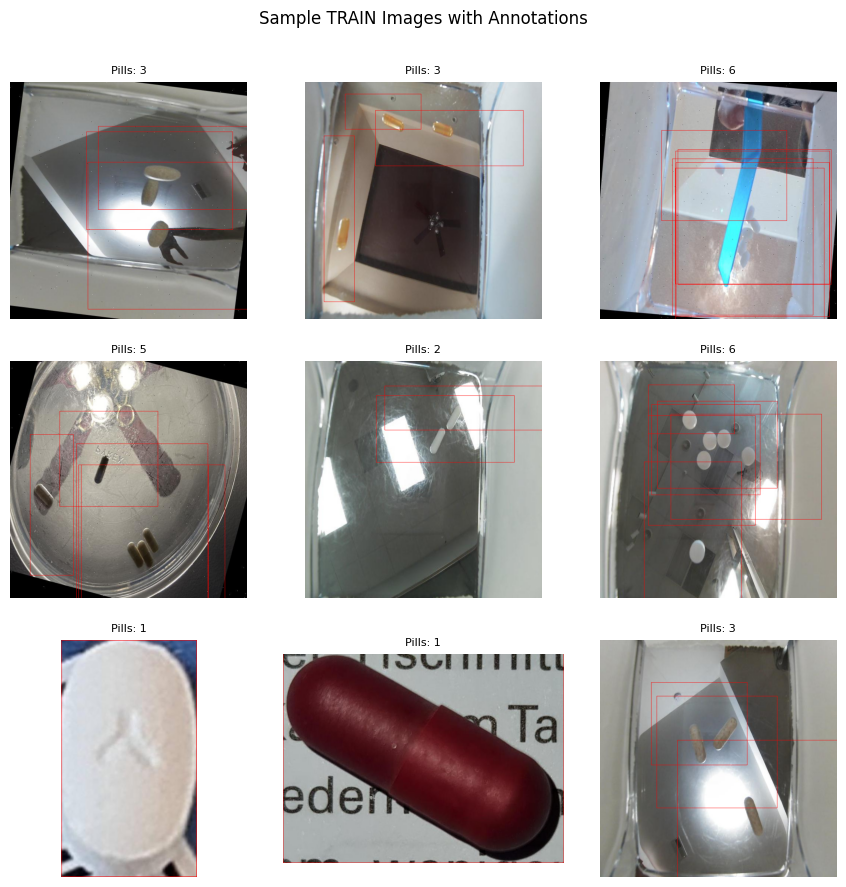

VAL: 688 images, 688 labels


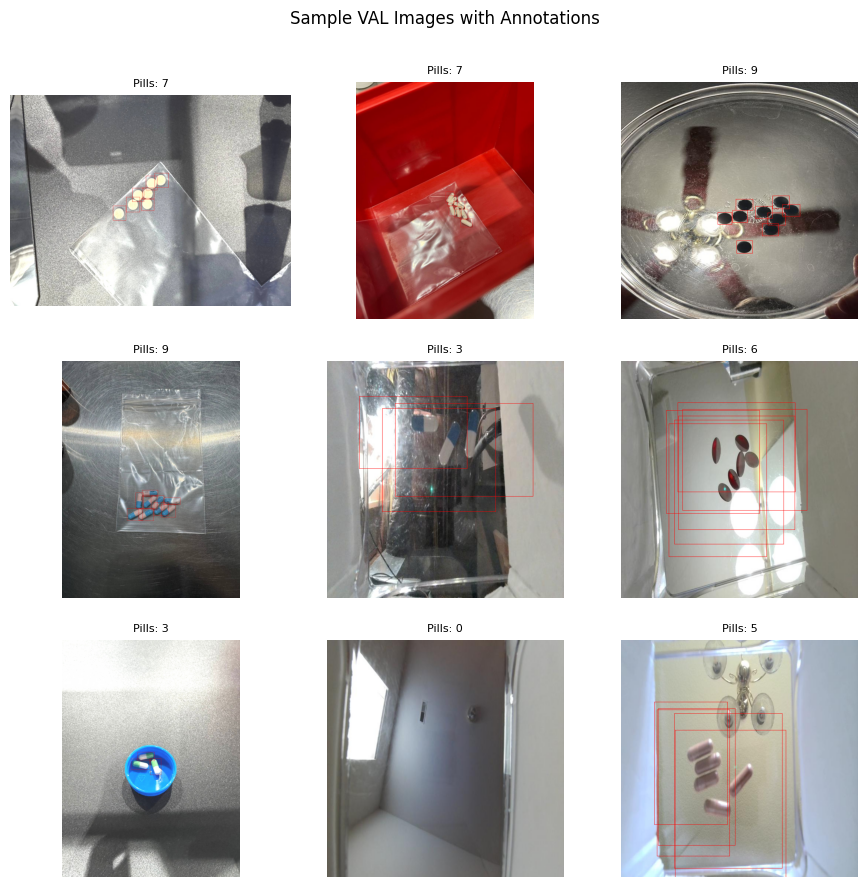

TEST: 325 images, 325 labels


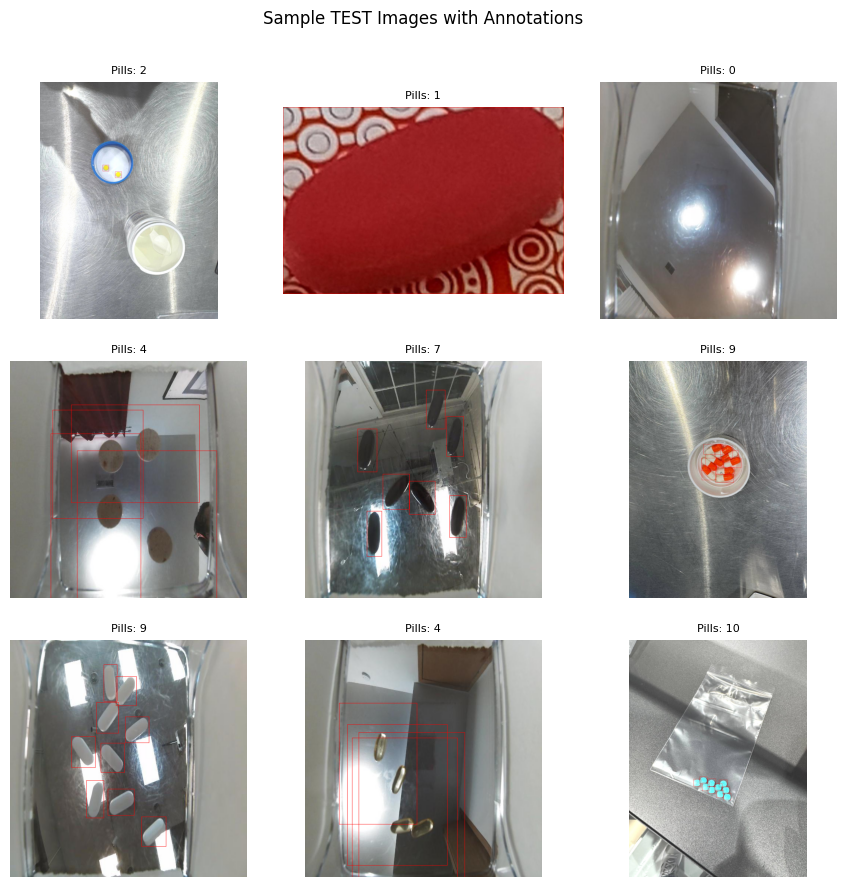

In [7]:
# Analyze Combined Dataset

def analyze_dataset(dataset_dir):
    splits_info = {}

    for split in ['train', 'val', 'test']:
        img_dir = dataset_dir / split / 'images'
        label_dir = dataset_dir / split / 'labels'

        if not img_dir.exists():
            print(f"{split.upper()}: No image directory found.")
            continue

        images = list(img_dir.glob('*'))
        labels = list(label_dir.glob('*')) if label_dir.exists() else []
        splits_info[split] = {'images': len(images), 'labels': len(labels)}
        print(f"{split.upper()}: {len(images)} images, {len(labels)} labels")

        if len(images) == 0:
            continue

        sample_images = random.sample(images, min(9, len(images)))

        fig, axes = plt.subplots(3, 3, figsize=(9, 9))
        fig.suptitle(f'Sample {split.upper()} Images with Annotations', fontsize=12)

        for idx in range(9):
            row, col = divmod(idx, 3)
            ax = axes[row][col]
            ax.axis('off')

            if idx >= len(sample_images):
                continue

            img_path = sample_images[idx]
            img = cv2.imread(str(img_path))
            if img is None:
                print(f"Unable to read image: {img_path}")
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Draw bounding boxes
            pill_count = 0
            label_path = label_dir / f"{img_path.stem}.txt"
            if label_path.exists():
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                    pill_count = len(lines)

                    h, w = img_rgb.shape[:2]
                    for line in lines:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            x_center, y_center, width, height = map(float, parts[1:5])
                            x1 = int((x_center - width / 2) * w)
                            y1 = int((y_center - height / 2) * h)
                            x2 = int((x_center + width / 2) * w)
                            y2 = int((y_center + height / 2) * h)
                            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 1)

            ax.imshow(img_rgb)
            #ax.set_title(f'{img_path.name}\nPills: {pill_count}', fontsize=8)
            ax.set_title(f'\nPills: {pill_count}', fontsize=8)

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

    return splits_info

dataset_info = analyze_dataset(combined_dataset_dir)

In [8]:
def create_dataset_yaml(dataset_path):
    """Create YAML configuration for the dataset"""
    yaml_content = {
        'path': '/content/combined_pill_dataset',
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'names': {
            0: 'pill'  # Assuming single class for pills/tablets
        },
        'nc': 1  # number of classes
    }

    yaml_path = dataset_path / 'dataset.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False)

    print(f"Dataset YAML created at: {yaml_path}")
    return yaml_path

data_yaml_path = create_dataset_yaml(combined_dataset_dir)

Dataset YAML created at: /content/combined_pill_dataset/dataset.yaml


In [ ]:
# TRY TO RUN 100 FIRST THEN TRY RESUME BELOW
def train_yolo_model(dataset_yaml_path, device='auto'):
    """Train YOLO model with the prepared dataset"""
    print("\n=== Starting YOLO Training ===")

    # Load pre-trained YOLOv8 model
    model = YOLO('yolov8m.pt')  # 2/12 use 'm' to enhance training

    # Training parameters
    training_args = {
        'data': str(dataset_yaml_path),
        'epochs': 100,  # Adjust based on your needs
        'imgsz': 800,   # Image size
        'batch': 16,    # Batch size - adjust based on GPU memory
        'device': device,
        'workers': 4,   # Number of worker threads
        'patience': 50, # Increased for more training tolerance
        'save': True,
        'save_period': 10,  # Save checkpoint every 10 epochs
        'cache': False,     # Set to True if you have enough RAM

        # Enhanced augmentation for tablet counting
        'augment': True,    # Data augmentation
        'mosaic': 0.8,      # Mosaic augmentation probability
        'mixup': 0.05,       # Mixup augmentation probability
        'copy_paste': 0.05,  # Copy-paste augmentation probability
        'degrees': 5,      # Rotation degrees
        'translate': 0.1,   # Translation
        'scale': 0.3,       # Scale
        'shear': 1.0,       # Shear
        'perspective': 0.0, # Perspective
        'flipud': 0.5,      # Vertical flip probability
        'fliplr': 0.5,      # Horizontal flip probability
        'hsv_h': 0.015,     # HSV hue augmentation
        'hsv_s': 0.5,       # HSV saturation augmentation
        'hsv_v': 0.3,       # HSV value augmentation

        # Optimized learning parameters
        'lr0': 0.01,       # Lower learning rate for fine-tuning
        'lrf': 0.001,        # Final learning rate
        'momentum': 0.937,
        'weight_decay': 0.0005,  # Add regularization

        # Additional optimizations
        'warmup_epochs': 3,
        'warmup_momentum': 0.8,
        'warmup_bias_lr': 0.1,
        'cos_lr': True,      # Cosine LR schedule
        'close_mosaic': 20,  # Disable mosaic in last 20 epochs
        'amp': True,         # Mixed precision
        'fraction': 1.0,     # Use all data
        'val': True,
        'plots': True,
    }

    # Adjust batch size based on device
    if device == 'cpu' or not torch.cuda.is_available():
        training_args['batch'] = 4  # Smaller batch for CPU
        training_args['workers'] = 2
        print("Using CPU optimized settings")
    else:
        # Check GPU memory and adjust batch size
        if torch.cuda.is_available():
            gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
            print(f"GPU Memory: {gpu_memory:.1f} GB")

            if gpu_memory < 8:
                training_args['batch'] = 8
            elif gpu_memory < 16:
                training_args['batch'] = 16
            else:
                training_args['batch'] = 32
            print(f"Using GPU with batch size: {training_args['batch']}")

    print(f"Training configuration:")
    for key, value in training_args.items():
        print(f"  {key}: {value}")

    # Start training
    start_time = time.time()
    results = model.train(**training_args)
    end_time = time.time()

    training_time = end_time - start_time
    print(f"\nTraining completed in {training_time/3600:.2f} hours")

    return model, results

print("Start training...")
model, results = train_yolo_model(data_yaml_path, device='auto')

Start training...

=== Starting YOLO Training ===
GPU Memory: 14.7 GB
Using GPU with batch size: 16
Training configuration:
  data: /content/combined_pill_dataset/dataset.yaml
  epochs: 150
  imgsz: 800
  batch: 16
  device: auto
  workers: 4
  patience: 50
  save: True
  save_period: 10
  cache: False
  augment: True
  mosaic: 0.8
  mixup: 0.05
  copy_paste: 0.05
  degrees: 5
  translate: 0.1
  scale: 0.3
  shear: 1.0
  perspective: 0.0
  flipud: 0.5
  fliplr: 0.5
  hsv_h: 0.015
  hsv_s: 0.5
  hsv_v: 0.3
  lr0: 0.01
  lrf: 0.001
  momentum: 0.937
  weight_decay: 0.0005
  warmup_epochs: 3
  warmup_momentum: 0.8
  warmup_bias_lr: 0.1
  cos_lr: True
  close_mosaic: 20
  amp: True
  fraction: 1.0
  val: True
  plots: True
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:auto (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=

In [ ]:
# RESUME TRAINING DOESNT WORK?

def resume_yolo_training(checkpoint_dir="/content/drive/MyDrive/Model (GPU)/runs/detect"):
    print("\n=== RESUME YOLO TRAINING ===")

    runs_dir = Path(checkpoint_dir)

    # Debug print so we KNOW the function is running
    print(f"Looking inside: {runs_dir}")

    if not runs_dir.exists():
        print("The directory does NOT exist. Cannot resume.")
        return None, None

    # Find train folders
    train_dirs = sorted([d for d in runs_dir.glob("train*") if d.is_dir()])
    print(f"Found train directories: {[d.name for d in train_dirs]}")

    if not train_dirs:
        print("No train directories found. Cannot resume.")
        return None, None

    # Select most recent
    last_run = train_dirs[-1]
    last_pt = last_run / "weights" / "last.pt"

    print(f"Checking checkpoint: {last_pt}")

    if not last_pt.exists():
        print("last.pt not found. Cannot resume training.")
        return None, None

    print(f"✔ Resuming from checkpoint: {last_pt}")
    model = YOLO(str(last_pt))

    # MUST NOT pass args
    results = model.train(resume=True)

    print("✔ Resume training started...")
    return model, results

model, results = resume_yolo_training()


=== RESUME YOLO TRAINING ===
Looking inside: /content/drive/MyDrive/Model (GPU)/runs/detect
Found train directories: ['train', 'train2', 'train3', 'train4', 'train5', 'train6', 'train7']
Checking checkpoint: /content/drive/MyDrive/Model (GPU)/runs/detect/train7/weights/last.pt
✔ Resuming from checkpoint: /content/drive/MyDrive/Model (GPU)/runs/detect/train7/weights/last.pt
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:auto (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/combined_pill_dataset/dataset.yaml, degrees=5, deterministic=True, device=auto, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half

In [ ]:
# RESUME TRAINING PART 2 (8/12)

def resume_yolo_training(checkpoint_dir="/content/drive/MyDrive/Model (GPU)/runs/detect"):
    print("\n=== RESUME YOLO TRAINING ===")

    runs_dir = Path(checkpoint_dir)

    # Debug print so we KNOW the function is running
    print(f"Looking inside: {runs_dir}")

    if not runs_dir.exists():
        print("The directory does NOT exist. Cannot resume.")
        return None, None

    # Find train folders
    train_dirs = sorted([d for d in runs_dir.glob("train*") if d.is_dir()])
    print(f"Found train directories: {[d.name for d in train_dirs]}")

    if not train_dirs:
        print("No train directories found. Cannot resume.")
        return None, None

    # Select most recent
    last_run = train_dirs[-1]
    last_pt = last_run / "weights" / "last.pt"

    print(f"Checking checkpoint: {last_pt}")

    if not last_pt.exists():
        print("last.pt not found. Cannot resume training.")
        return None, None

    print(f"✔ Resuming from checkpoint: {last_pt}")
    model = YOLO(str(last_pt))

    # MUST NOT pass args
    results = model.train(resume=True)

    print("✔ Resume training started...")
    return model, results

model, results = resume_yolo_training()


=== RESUME YOLO TRAINING ===
Looking inside: /content/drive/MyDrive/Model (GPU)/runs/detect
Found train directories: ['train', 'train2', 'train3', 'train4', 'train5', 'train6', 'train7']
Checking checkpoint: /content/drive/MyDrive/Model (GPU)/runs/detect/train7/weights/last.pt
✔ Resuming from checkpoint: /content/drive/MyDrive/Model (GPU)/runs/detect/train7/weights/last.pt
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:auto (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/combined_pill_dataset/dataset.yaml, degrees=5, deterministic=True, device=auto, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half

In [9]:
# RESUME TRAINING PART 3 (16/12)

def resume_yolo_training(checkpoint_dir="/content/drive/MyDrive/Model (GPU)/runs/detect"):
    print("\n=== RESUME YOLO TRAINING ===")

    runs_dir = Path(checkpoint_dir)

    # Debug print so we KNOW the function is running
    print(f"Looking inside: {runs_dir}")

    if not runs_dir.exists():
        print("The directory does NOT exist. Cannot resume.")
        return None, None

    # Find train folders
    train_dirs = sorted([d for d in runs_dir.glob("train*") if d.is_dir()])
    print(f"Found train directories: {[d.name for d in train_dirs]}")

    if not train_dirs:
        print("No train directories found. Cannot resume.")
        return None, None

    # Select most recent
    last_run = train_dirs[-1]
    last_pt = last_run / "weights" / "last.pt"

    print(f"Checking checkpoint: {last_pt}")

    if not last_pt.exists():
        print("last.pt not found. Cannot resume training.")
        return None, None

    print(f"✔ Resuming from checkpoint: {last_pt}")
    model = YOLO(str(last_pt))

    # MUST NOT pass args
    results = model.train(resume=True)

    print("✔ Resume training started...")
    return model, results

model, results = resume_yolo_training()


=== RESUME YOLO TRAINING ===
Looking inside: /content/drive/MyDrive/Model (GPU)/runs/detect
Found train directories: ['train', 'train2', 'train3', 'train4', 'train5', 'train6', 'train7']
Checking checkpoint: /content/drive/MyDrive/Model (GPU)/runs/detect/train7/weights/last.pt
✔ Resuming from checkpoint: /content/drive/MyDrive/Model (GPU)/runs/detect/train7/weights/last.pt
Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:auto (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/combined_pill_dataset/dataset.yaml, degrees=5, deterministic=True, device=auto, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half


image 1/1 c:\Users\Jia Yi Chow\Desktop\Model (2)\levo.jpg: 800x608 13 pills, 487.6ms
Speed: 4.9ms preprocess, 487.6ms inference, 2.6ms postprocess per image at shape (1, 3, 800, 608)
Pills detected: 13


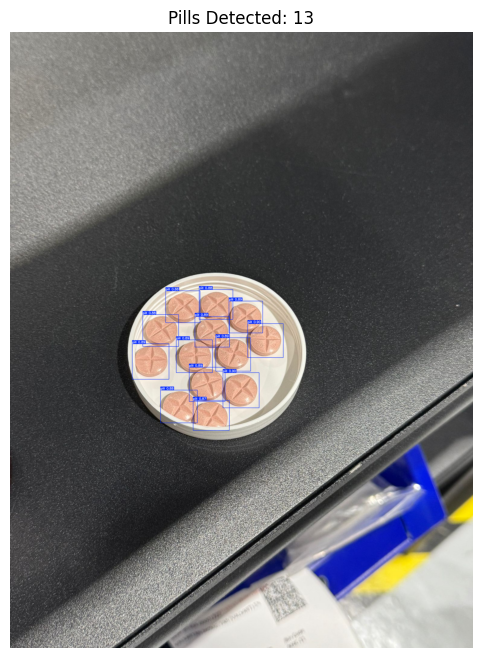

In [ ]:
# Load your best trained model
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO(r"C:\Users\Jia Yi Chow\Desktop\Model (2)\runs\detect\trainL (150)\weights\best.pt")

# Make predictions
results = model('levo.jpg', conf=0.45)
pill_count = len(results[0].boxes) if results[0].boxes is not None else 0
print(f"Pills detected: {pill_count}")

# Method 1: Use YOLO's built-in plotting with custom line width
plotted = results[0].plot(line_width=1)  # Thinner lines (default is usually 3)
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Pills Detected: {pill_count}')
plt.show()

# Web Application

In [ ]:
%%writefile app95.py
import streamlit as st
from PIL import Image, ImageDraw
import numpy as np
from ultralytics import YOLO

st.set_page_config(page_title="Tablet Counter", layout="wide")

@st.cache_resource
def load_model():
    try:
        model = YOLO("best50.pt")  # Make sure best50.pt is in the same folder
        return model
    except Exception as e:
        st.error(f"Error loading model: {str(e)}")
        return None

def model_count_tablets_with_boxes(image, model):
    """Run YOLO detection, count tablets, and draw bounding boxes"""
    if model is None:
        return 0, image

    try:
        img_array = np.array(image)
        results = model(img_array)

        tablet_count = 0
        draw_image = image.copy()
        draw = ImageDraw.Draw(draw_image)

        for result in results:
            if result.boxes is not None:
                tablet_count += len(result.boxes)
                for box in result.boxes.xyxy:  # xyxy = [x1, y1, x2, y2]
                    x1, y1, x2, y2 = map(int, box)
                    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

        return tablet_count, draw_image
    except Exception as e:
        st.error(f"Error during inference: {str(e)}")
        return 0, image

# ---------------- STREAMLIT UI ----------------
st.title("Tablet Counter")
st.write("Upload an image OR use your camera to count tablets")

# Load model
with st.spinner("Loading model..."):
    model = load_model()

if model is None:
    st.stop()

# File uploader
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

# Camera option
use_camera = st.checkbox("Use Camera")

# ---------- File Upload Mode ----------
if uploaded_file is not None and not use_camera:
    image = Image.open(uploaded_file)

    if st.button("Count Tablets from File", type="primary"):
        count, boxed_image = model_count_tablets_with_boxes(image, model)
        st.image(boxed_image, caption=f"Detected Tablets: {count}", use_container_width=True)
        if count > 0:
            st.success(f"Number of tablets detected: {count}")
        else:
            st.warning("No tablets detected")

# ---------- Camera Mode ----------
elif use_camera:
    camera_file = st.camera_input("Take a photo with your camera")

    if camera_file is not None:
        image = Image.open(camera_file)

        if st.button("Count Tablets from Camera", type="primary"):
            count, boxed_image = model_count_tablets_with_boxes(image, model)
            st.image(boxed_image, caption=f"Detected Tablets: {count}", use_container_width=True)
            if count > 0:
                st.success(f"Number of tablets detected: {count}")
            else:
                st.warning("No tablets detected")